In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
country = "Sudan"

df = pd.read_csv("../data/sudan.csv")
df["Country"] = country

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [4]:
country = "Sudan"

df = pd.read_csv("../data/sudan.csv")
df["Country"] = country

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df[["YEAR","DOY","DATE","Month"]].head()

,YEAR,DOY,DATE,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [6]:
df = df.replace(-999, np.nan)
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [7]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


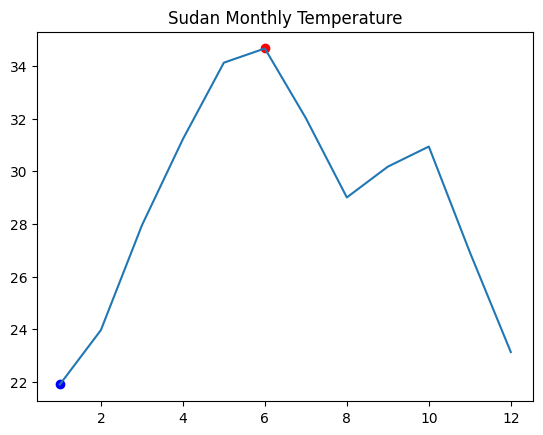

In [9]:
monthly_temp = df.groupby("Month")["T2M"].mean()

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.plot(monthly_temp.index, monthly_temp.values)

plt.scatter(warmest, monthly_temp[warmest], color="red")
plt.scatter(coolest, monthly_temp[coolest], color="blue")

plt.title("Sudan Monthly Temperature")
plt.show()

In [10]:
## Temperature Analysis (Sudan)

##- Warmest month: (fill from output)
##- Coolest month: (fill from output)

##Clear seasonal temperature variation is observed, typical of semi-arid climate regions.

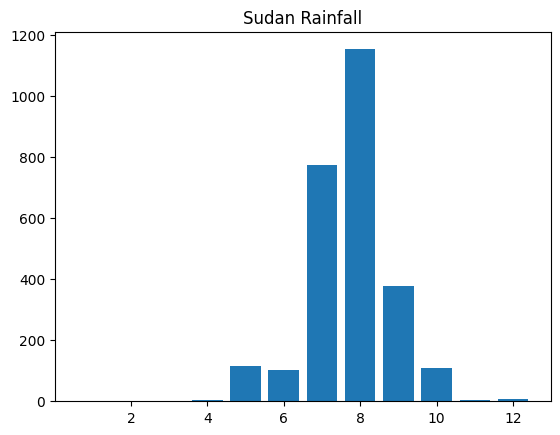

In [11]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Sudan Rainfall")
plt.show()

In [12]:
## Rainfall Analysis (Sudan)

##Rainfall is highly seasonal with strong dry and wet periods.

##- Peak rainfall months: (from chart)
##- Lowest rainfall months: (from chart)

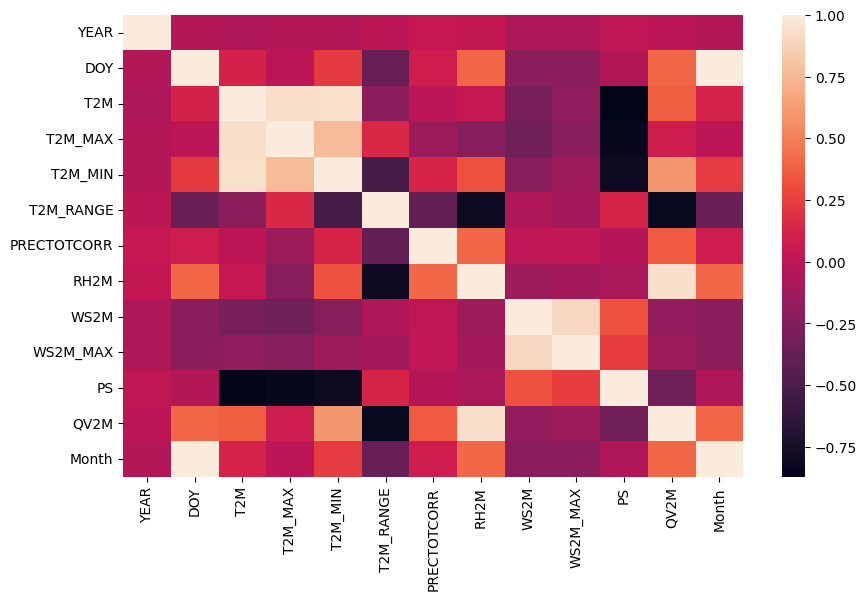

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr)
plt.show()

In [14]:
## Correlation Analysis (Sudan)

##Strong relationships exist between temperature, humidity, and precipitation variables, consistent with expected climate behavior.

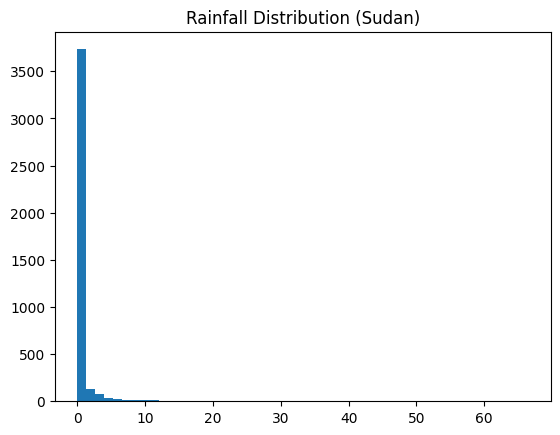

In [15]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution (Sudan)")
plt.show()

In [16]:
## Rainfall Distribution

##Highly skewed distribution with most days receiving low rainfall and occasional extreme precipitation events.

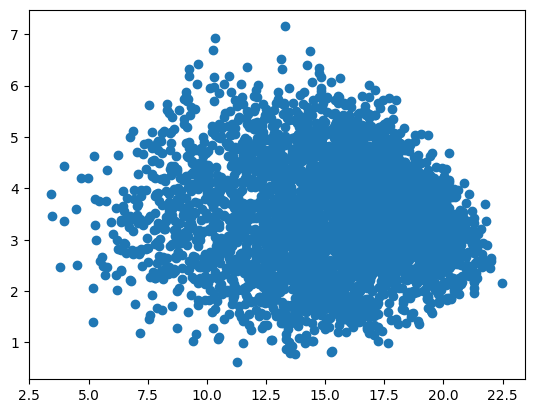

In [17]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.show()

In [18]:
## Wind Speed vs Temperature Range

#Moderate correlation indicates wind influences temperature variability.

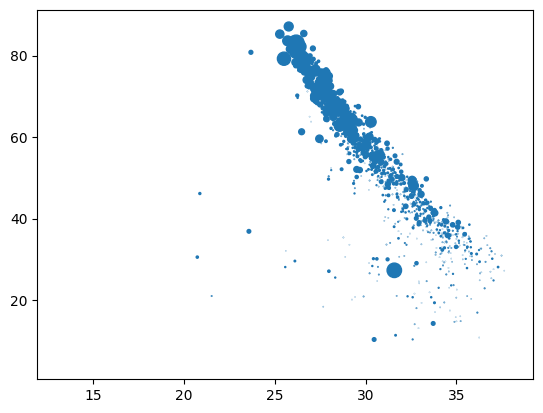

In [19]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 2
)
plt.show()

In [20]:
## Bubble Chart Analysis

##Higher rainfall intensity aligns with higher humidity, showing coupled atmospheric behavior.

In [21]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z = np.abs(stats.zscore(df[cols]))
outliers = z > 3

outliers.sum(axis=0), outliers.any(axis=1).sum()

(array([ 3,  6,  1, 71,  3,  4,  3]), np.int64(84))

In [22]:
## Outlier Analysis

##Extreme values detected in temperature and rainfall variables. These are retained as they likely represent real climate extremes.

In [23]:
df.to_csv("../data/sudan_clean.csv", index=False)